### MODEL BUILDING FOR PCOS PREDICTION


In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)
df=pd.read_csv("Feature Engnineered dataset.csv")
df.loc[df['pcos']==1]

,pcos,age,weight,height,bmi,had_abortion,blood_group,cycle_type,marriage_years,pregnant,weight_gain,hair_growth,skin_darkening,hair_loss,pimples,fast_food,regular_exercise,pulse_rate,respiratory_rate,hemoglobin,fsh,lh,lh_fsh_ratio,waist_hip_ratio,tsh,amh,prolactin,vitamin_d3,progesterone,random_blood_sugar,bp_systolic,bp_diastolic,avg_follicle_size,total_follicles,endometrium_thickness
2,1,33,68.8,1.65000,25.270891,0,A+,Regular,10.0,1,0,0,0,1,1,1.0,0,72,18,11.8,5.54,0.88,0.158845,0.900000,2.54,6.63,10.52,49.70,0.36,84.0,120,80,19.0,28,10.0
12,1,25,74.0,1.52000,32.029086,0,AB+,Irregular,7.0,1,1,1,1,1,1,1.0,1,72,18,11.7,2.00,1.51,0.755000,0.888889,6.51,7.94,22.43,31.40,0.30,125.0,120,80,20.5,23,8.0
19,1,30,85.0,1.65000,31.221304,0,O-,Irregular,7.0,0,0,1,1,1,1,1.0,0,72,18,12.5,1.89,0.81,0.428571,0.954545,2.87,2.07,19.13,28.00,0.30,100.0,120,80,17.5,24,11.0
24,1,34,63.0,1.58000,25.236340,0,A+,Regular,12.0,1,0,1,0,0,1,1.0,0,72,20,11.2,5.34,0.89,0.166667,0.842105,0.65,1.89,11.46,21.50,0.98,100.0,120,70,17.5,10,7.3
26,1,30,76.0,1.60000,29.687500,0,O+,Irregular,5.0,0,1,1,1,1,1,1.0,1,75,18,11.2,6.18,2.78,0.449838,0.844444,4.28,3.84,17.98,25.14,0.35,100.0,120,80,11.5,41,6.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,1,27,50.0,1.68000,17.715420,0,B+,Irregular,7.0,0,0,1,0,0,1,0.0,0,72,18,12.0,4.56,2.16,0.473684,0.961538,0.86,7.20,23.14,37.90,0.40,100.0,120,70,19.5,38,7.8
523,1,36,60.0,1.50000,26.666667,0,O+,Irregular,8.0,0,1,0,0,0,1,0.0,0,72,18,10.2,5.71,1.00,0.175131,0.952381,2.11,7.70,39.41,26.10,0.25,110.0,110,80,19.5,15,7.6
524,1,27,70.0,1.70688,24.026586,1,B+,Regular,4.0,1,1,0,0,0,0,0.0,0,72,18,11.5,4.30,2.04,0.474419,0.954545,3.65,0.19,9.83,21.80,0.50,107.0,120,80,22.0,19,6.5
533,1,26,53.5,1.61544,20.500862,0,B-,Irregular,3.0,0,0,0,0,0,1,0.0,0,70,18,10.6,3.71,4.66,1.256065,0.928571,1.40,19.60,29.57,32.10,0.36,100.0,110,80,18.0,18,10.3


In [3]:
df.shape

(541, 35)

In [4]:
# Creating a new dataset on which our model 1 will train taht will take column whose values users can easily fill without any 
#clinincal reports as input

In [5]:
df.columns

Index(['pcos', 'age', 'weight', 'height', 'bmi', 'had_abortion', 'blood_group',
       'cycle_type', 'marriage_years', 'pregnant', 'weight_gain',
       'hair_growth', 'skin_darkening', 'hair_loss', 'pimples', 'fast_food',
       'regular_exercise', 'pulse_rate', 'respiratory_rate', 'hemoglobin',
       'fsh', 'lh', 'lh_fsh_ratio', 'waist_hip_ratio', 'tsh', 'amh',
       'prolactin', 'vitamin_d3', 'progesterone', 'random_blood_sugar',
       'bp_systolic', 'bp_diastolic', 'avg_follicle_size', 'total_follicles',
       'endometrium_thickness'],
      dtype='object')

In [6]:
df1=df[['pcos', 'age', 'weight', 'height', 'bmi', 'had_abortion', 'blood_group',
       'cycle_type', 'marriage_years', 'pregnant', 'weight_gain',
       'hair_growth', 'skin_darkening', 'hair_loss', 'pimples', 'fast_food',
       'regular_exercise', 'pulse_rate']]

In [7]:
df1.head(3)

,pcos,age,weight,height,bmi,had_abortion,blood_group,cycle_type,marriage_years,pregnant,weight_gain,hair_growth,skin_darkening,hair_loss,pimples,fast_food,regular_exercise,pulse_rate
0,0,28,44.6,1.520,19.304017,0,O+,Regular,7.0,0,0,0,0,0,0,1.0,0,78
1,0,36,65.0,1.615,24.921163,0,O+,Regular,11.0,1,0,0,0,0,0,0.0,0,74
2,1,33,68.8,1.650,25.270891,0,A+,Regular,10.0,1,0,0,0,1,1,1.0,0,72


In [8]:
### training model 1
import mlflow

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
mlflow.set_tracking_uri("sqlite:////Users/atharvashinde/Desktop/Pcos api/mlflow.db")
mlflow.set_experiment("Pcos-model 1 training")


2026/06/04 11:44:08 INFO mlflow.tracking.fluent: Experiment with name 'Pcos-model 1 training' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/atharvashinde/mlruns/1', creation_time=1780553648474, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780553648474, lifecycle_stage='active', name='Pcos-model 1 training', tags={}, trace_location=None, workspace='default'>

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df1.drop('pcos',axis=1),df1['pcos'],test_size=0.25,random_state=42,stratify=df1['pcos'])

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [15]:
x_train.isna().sum()

age                 0
weight              0
height              0
bmi                 0
had_abortion        0
blood_group         0
cycle_type          0
marriage_years      1
pregnant            0
weight_gain         0
hair_growth         0
skin_darkening      0
hair_loss           0
pimples             0
fast_food           1
regular_exercise    0
pulse_rate          0
dtype: int64

In [16]:
numeric=['age', 'weight', 'height', 'bmi', 'had_abortion','marriage_years', 'pregnant', 'weight_gain',
       'hair_growth', 'skin_darkening', 'hair_loss', 'pimples', 'fast_food',
       'regular_exercise', 'pulse_rate']
imputation_cols=['marriage_years','fast_food']
ohe_col=['blood_group']
ordinal_encode_col=['cycle_type']

In [17]:
from sklearn.pipeline import Pipeline
numeric_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])


In [18]:
transformer=ColumnTransformer(transformers=
                              [
                               ('tnf1',numeric_pipeline,numeric),
                               ('tnf2',OneHotEncoder(drop='first',handle_unknown='ignore'),ohe_col),
                               ('tnf3',OrdinalEncoder(categories=[['Regular','Irregular']]),ordinal_encode_col)],
                               remainder='passthrough')
x_train_transformed=transformer.fit_transform(x_train)
x_test_transformed=transformer.transform(x_test)

In [19]:
### handling imbalanced data by computing class weight and assigning those class weight in the model
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))


### calculating scale_pos_weights for XGBoost this the type of class weight used in xgboost
scale_pos_weight = 364 / 177   #where 364=no.of 0's, 177=no.of 1's

In [29]:
from sklearn.metrics import accuracy_score,recall_score,precision_score
from sklearn.metrics import classification_report

with mlflow.start_run(run_name='XGB'):
    model1=XGBClassifier(scale_pos_weight=scale_pos_weight)
    mlflow.autolog()
    model1.fit(x_train_transformed,y_train)
    y_pred1=model1.predict(x_test_transformed)
    mlflow.log_param("model_name","XGB")
    mlflow.log_metric("accuracy_score",accuracy_score(y_test,y_pred1))
    report=classification_report(y_test,y_pred1,output_dict=True)
    mlflow.log_metric("recall_class_0",report['0']['recall'])
    mlflow.log_metric("recall_class_1",report['1']['recall'])
    mlflow.log_metric("precision_class_0",report['0']['precision'])
    mlflow.log_metric("precision_class_1",report['1']['precision'])



    

    


2026/06/04 12:03:28 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/04 12:03:28 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/06/04 12:03:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [30]:
with mlflow.start_run(run_name='RandomForest'):
    model2=RandomForestClassifier(class_weight=class_weight)
    mlflow.autolog()
    model2.fit(x_train_transformed,y_train)
    y_pred2=model2.predict(x_test_transformed)
    mlflow.log_param("model_name","Random Forest")
    mlflow.log_metric("accuracy_score",accuracy_score(y_test,y_pred2))
    report2=classification_report(y_test,y_pred2,output_dict=True)
    mlflow.log_metric("recall_class_0",report2['0']['recall'])
    mlflow.log_metric("recall_class_1",report2['1']['recall'])
    mlflow.log_metric("precision_class_0",report2['0']['precision'])
    mlflow.log_metric("precision_class_1",report2['1']['precision'])

2026/06/04 12:04:16 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/04 12:04:16 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/06/04 12:04:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/06/04 12:04:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [31]:
with mlflow.start_run(run_name='SVC'):
    model3=SVC(class_weight=class_weight)
    mlflow.autolog()
    model3.fit(x_train_transformed,y_train)
    y_pred3=model3.predict(x_test_transformed)
    mlflow.log_param("model_name","SVC")
    mlflow.log_metric("accuracy_score",accuracy_score(y_test,y_pred3))
    report3=classification_report(y_test,y_pred3,output_dict=True)
    mlflow.log_metric("recall_class_0",report3['0']['recall'])
    mlflow.log_metric("recall_class_1",report3['1']['recall'])
    mlflow.log_metric("precision_class_0",report3['0']['precision'])
    mlflow.log_metric("precision_class_1",report3['1']['precision'])

2026/06/04 12:04:40 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/04 12:04:40 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/06/04 12:04:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/06/04 12:04:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [91]:
### lets see classification report

In [24]:
from sklearn.metrics import classification_report
print(f"Report of model 1:- {classification_report(y_test,y_pred1)}")


Report of model 1:-               precision    recall  f1-score   support

           0       0.83      0.90      0.86        92
           1       0.75      0.61      0.68        44

    accuracy                           0.81       136
   macro avg       0.79      0.76      0.77       136
weighted avg       0.80      0.81      0.80       136



In [93]:
print(f"Report of model 2:- {classification_report(y_test,y_pred2)}")


Report of model 2:-               precision    recall  f1-score   support

           0       0.85      0.91      0.88        92
           1       0.78      0.66      0.72        44

    accuracy                           0.83       136
   macro avg       0.82      0.79      0.80       136
weighted avg       0.83      0.83      0.83       136



In [94]:

print(f"Report of model 3:- {classification_report(y_test,y_pred3)}")


Report of model 3:-               precision    recall  f1-score   support

           0       0.89      0.88      0.89        92
           1       0.76      0.77      0.76        44

    accuracy                           0.85       136
   macro avg       0.82      0.83      0.82       136
weighted avg       0.85      0.85      0.85       136



In [95]:
df1['pcos'].value_counts()

pcos
0    364
1    177
Name: count, dtype: int64

In [97]:

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score,make_scorer



param_grid = {'kernel':['linear', 'poly', 'rbf', 'sigmoid'],
              'C':[0.1, 1, 10, 100],
              'gamma':['scale', 'auto'],
              'class_weight':[None,'balanced']}
recall_pos = make_scorer(recall_score, pos_label=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(estimator=model3,param_grid=param_grid,scoring=recall_pos,cv=cv,n_jobs=-1,verbose=1
)

gs.fit(x_train_transformed, y_train)

print("Best params:", gs.best_params_)
print("Best CV recall (class 1):", gs.best_score_)


Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params: {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best CV recall (class 1): 0.8116809116809117


In [34]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import recall_score,make_scorer
param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5],
    "scale_pos_weight": [1, 2, 3]
}
recall_pos = make_scorer(recall_score, pos_label=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs2 = RandomizedSearchCV(estimator=model1,param_distributions=param_grid_xgb,scoring=recall_pos,cv=cv,n_jobs=-1,verbose=1
)

gs2.fit(x_train_transformed, y_train)

print("Best params:", gs2.best_params_)
print("Best CV recall (class 1):", gs2.best_score_)

2026/06/04 12:27:02 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2a2574ffe85849caa23cd1fee7953dbd', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/04 12:27:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Fitting 5 folds for each of 10 candidates, totalling 50 fits


2026/06/04 12:27:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/04 12:27:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/04 12:27:11 INFO mlflow.sklearn.utils: Logging the 5 best runs, 5 runs will be omitted.
2026/06/04 12:27:11 WARNING mlflow.sklearn: Encountered exception during creation of child runs for pa

Best params: {'subsample': 0.7, 'scale_pos_weight': 3, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV recall (class 1): 0.7811965811965813


In [99]:
### better recall score is for xgboost moving forward with it and its param

In [36]:
with mlflow.start_run(run_name='XGB tuned'):
    
    xgb_model=gs2.best_estimator_
    xgb_model.fit(x_train_transformed,y_train)
    mlflow.autolog()
    y_pred_final=xgb_model.predict(x_test_transformed)
    mlflow.log_param("model_name","xgb_hypertuned")
    report5=classification_report(y_test,y_pred_final,output_dict=True)
    mlflow.log_metric("recall_class_0",report5['0']['recall'])
    mlflow.log_metric("recall_class_1",report5['1']['recall'])
    mlflow.log_metric("precision_class_0",report5['0']['precision'])
    mlflow.log_metric("precision_class_1",report5['1']['precision'])

2026/06/04 12:29:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 12:29:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/04 12:29:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


In [101]:
final_classification_report=classification_report(y_test,y_pred_final)
print(final_classification_report)

              precision    recall  f1-score   support

           0       0.91      0.77      0.84        92
           1       0.64      0.84      0.73        44

    accuracy                           0.79       136
   macro avg       0.77      0.81      0.78       136
weighted avg       0.82      0.79      0.80       136



In [102]:
####  apply roc-auc

In [38]:
from sklearn.metrics import roc_curve
y_pred_proba=xgb_model.predict_proba(x_test_transformed)[:,1]
fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

In [39]:
performances=tpr-fpr
best_idx=np.argmax(performances)
best_threshold=threshold[best_idx]

In [40]:
best_threshold

np.float32(0.51095444)

In [41]:
y_pred_final=(y_pred_proba>best_threshold).astype(int)

In [42]:
### now final peformance
print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        92
           1       0.76      0.80      0.78        44

    accuracy                           0.85       136
   macro avg       0.83      0.84      0.83       136
weighted avg       0.85      0.85      0.85       136



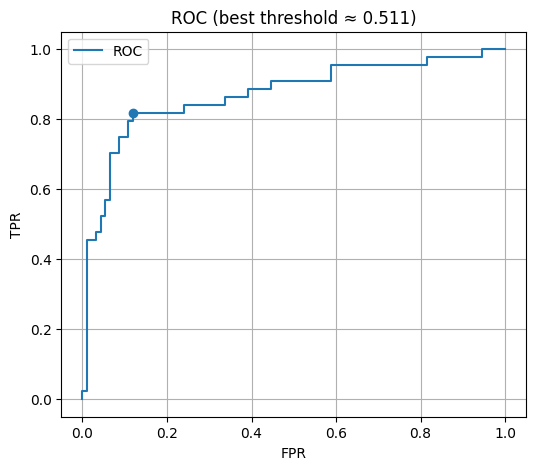

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC")
plt.scatter(fpr[best_idx], tpr[best_idx], marker="o")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"ROC (best threshold ≈ {best_threshold:.3f})")
plt.grid(True)
plt.legend()
plt.show()

In [44]:
## as the thresh selected by the roc curve has reduced our recall_score lets try some other thresh

In [45]:
thresh_val=[0.54,0.52,0.5,0.43,0.4,0.35,0.3]
for i in thresh_val:
    y_pred_t=(y_pred_proba>i).astype(int)
    print(f"For Thresh value of '{i}':-")
    print(classification_report(y_test,y_pred_t))

For Thresh value of '0.54':-
              precision    recall  f1-score   support

           0       0.90      0.89      0.90        92
           1       0.78      0.80      0.79        44

    accuracy                           0.86       136
   macro avg       0.84      0.84      0.84       136
weighted avg       0.86      0.86      0.86       136

For Thresh value of '0.52':-
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        92
           1       0.76      0.80      0.78        44

    accuracy                           0.85       136
   macro avg       0.83      0.84      0.83       136
weighted avg       0.85      0.85      0.85       136

For Thresh value of '0.5':-
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        92
           1       0.75      0.82      0.78        44

    accuracy                           0.85       136
   macro avg       0.83      0.84      0.8

In [47]:
# selecting best thresh=0.54
final_thresh=0.54

with mlflow.start_run(run_name="XGB_param_thresh_tuned"):
    y_pred_final=(y_pred_proba>final_thresh).astype(int)
    mlflow.log_param("model_name","XGB_param_thresh_tuned")
    mlflow.log_param("Threshold","0.54")
    final_report=classification_report(y_test,y_pred_final,output_dict=True)
    mlflow.log_metric("recall_class_0",final_report['0']['recall'])
    mlflow.log_metric("recall_class_1",final_report['1']['recall'])
    mlflow.log_metric("precision_class_0",final_report['0']['precision'])
    mlflow.log_metric("precision_class_1",final_report['1']['precision'])
    mlflow.xgboost.log_model(xgb_model,"final_model")


2026/06/04 12:53:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [112]:
### locking this model1 for deployment

In [113]:
### checking the versions of libraries i have use
import xgboost
import sklearn
print("Numpy version",np.__version__)
print("Pandas version",pd.__version__)
print("XGBOOST version",xgboost.__version__)
print("SKLEARN version",sklearn.__version__)

Numpy version 2.4.1
Pandas version 3.0.0
XGBOOST version 3.1.3
SKLEARN version 1.8.0


In [114]:
### downloading the model

In [117]:
import pickle
bundle={"transformer":transformer,
        "model":xgb_model,
        "threshold":final_thresh}
pickle_model_path="model_1.pkl"
with open(pickle_model_path,"wb") as f:
    pickle.dump(bundle,f)

In [118]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pcos              541 non-null    int64  
 1   age               541 non-null    int64  
 2   weight            541 non-null    float64
 3   height            541 non-null    float64
 4   bmi               541 non-null    float64
 5   had_abortion      541 non-null    int64  
 6   blood_group       541 non-null    str    
 7   cycle_type        541 non-null    str    
 8   marriage_years    540 non-null    float64
 9   pregnant          541 non-null    int64  
 10  weight_gain       541 non-null    int64  
 11  hair_growth       541 non-null    int64  
 12  skin_darkening    541 non-null    int64  
 13  hair_loss         541 non-null    int64  
 14  pimples           541 non-null    int64  
 15  fast_food         540 non-null    float64
 16  regular_exercise  541 non-null    int64  
 17  pulse_ra

In [120]:
df1['blood_group'].unique()

<ArrowStringArray>
['O+', 'A+', 'B+', 'AB+', 'O-', 'A-', 'B-', 'AB-']
Length: 8, dtype: str

In [27]:
report=classification_report(y_test,y_pred1)